In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.decomposition import PCA

In [ ]:
# Load the data
data = pd.read_csv('/content/preprocessed_data.csv')

# Display data
print("Data Sample:")
data.head()


Data Sample:


,budget,genres,original_language,original_title,overview,popularity,production_companies,production_countries,runtime,spoken_languages,revenue,release_year,release_month,release_day,profit,profit_margin
0,500000,"Drama, Horror, Thriller, Romance",en,May,Psychological horror about a lonely young woma...,8.398158,"A Loopy Production LLC, 2 Loop Films",United States of America,93.0,English,1.502770e+05,2002.0,1.0,13.0,-3.497230e+05,-0.699446
1,2300000,"Comedy, Crime, Thriller",en,Curdled,"Gabriella, a Columbian immigrant, is obsessed ...",2.781581,Tinderbox Films,United States of America,88.0,"English, Español",2.209826e+06,1996.0,9.0,6.0,-9.017376e+04,-0.039206
2,0,"Thriller, Action, Drama, War",en,'71,A young British soldier must find his way back...,7.080550,"Screen Yorkshire, British Film Institute (BFI)...",United Kingdom,99.0,English,1.625847e+06,2014.0,10.0,10.0,1.625847e+06,0.000000
3,2000000,"Adventure, Action, Thriller, Science Fiction",en,Mad Max 2,Max Rockatansky returns as the heroic loner wh...,11.189831,Kennedy Miller Productions,Australia,95.0,English,2.460083e+07,1981.0,12.0,24.0,2.260083e+07,6.643274
4,52000000,Drama,en,Apollo 13,The true story of technical troubles that scut...,18.761467,"Imagine Entertainment, Universal Pictures",United States of America,140.0,English,1.809885e+08,1995.0,6.0,30.0,1.197271e+08,5.831499


In [ ]:
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer

# Drop irrelevant columns
drop_cols = ['original_title', 'overview', 'production_companies']
data_cleaned = data.drop(columns=drop_cols)

# Function to split multi-value strings
def split_multi_entries(x):
    return [i.strip() for i in x.split(',')] if isinstance(x, str) else []

# Initialize encoders
mlb = MultiLabelBinarizer()
le = LabelEncoder()

# Encode 'genres' (multi-label)
genres_encoded = mlb.fit_transform(data_cleaned['genres'].apply(split_multi_entries))
genres_df = pd.DataFrame(genres_encoded, columns=[f"genre_{cls}" for cls in mlb.classes_])

# Encode 'spoken_languages' (multi-label)
languages_encoded = mlb.fit_transform(data_cleaned['spoken_languages'].apply(split_multi_entries))
languages_df = pd.DataFrame(languages_encoded, columns=[f"language_{cls}" for cls in mlb.classes_])

# Encode 'original_language' (single label)
data_cleaned['original_language_encoded'] = le.fit_transform(data_cleaned['original_language'])

# Encode 'production_countries' (multi-label)
countries_encoded = mlb.fit_transform(data_cleaned['production_countries'].apply(split_multi_entries))
countries_df = pd.DataFrame(countries_encoded, columns=[f"country_{cls}" for cls in mlb.classes_])

# Drop original string columns
data_cleaned = data_cleaned.drop(columns=['genres', 'original_language', 'production_countries', 'spoken_languages'])

# Concatenate all encoded features
data_final = pd.concat([data_cleaned.reset_index(drop=True), genres_df, languages_df, countries_df], axis=1)

# Display the shape of the final dataset
data_final.shape

data_final_filled = data_final.fillna(0)

In [ ]:
data_final_filled

,budget,popularity,runtime,revenue,release_year,release_month,release_day,profit,profit_margin,original_language_encoded,...,country_Taiwan,country_Thailand,country_Tunisia,country_Turkey,country_Ukraine,country_United Arab Emirates,country_United Kingdom,country_United States of America,country_Uruguay,country_Venezuela
0,500000,8.398158,93.0,1.502770e+05,2002.0,1.0,13.0,-3.497230e+05,-0.699446,10,...,0,0,0,0,0,0,0,1,0,0
1,2300000,2.781581,88.0,2.209826e+06,1996.0,9.0,6.0,-9.017376e+04,-0.039206,10,...,0,0,0,0,0,0,0,1,0,0
2,0,7.080550,99.0,1.625847e+06,2014.0,10.0,10.0,1.625847e+06,0.000000,10,...,0,0,0,0,0,0,1,0,0,0
3,2000000,11.189831,95.0,2.460083e+07,1981.0,12.0,24.0,2.260083e+07,6.643274,10,...,0,0,0,0,0,0,0,0,0,0
4,52000000,18.761467,140.0,1.809885e+08,1995.0,6.0,30.0,1.197271e+08,5.831499,10,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7393,42000000,10.536644,108.0,9.608210e+07,1991.0,6.0,21.0,5.408210e+07,1.287669,10,...,0,0,0,0,0,0,0,1,0,0
7394,0,2.624771,95.0,2.224714e+06,1995.0,5.0,26.0,2.224714e+06,0.000000,10,...,0,0,0,0,0,0,0,1,0,0
7395,12000000,8.321647,114.0,3.600727e+07,1983.0,6.0,3.0,2.400727e+07,2.000606,10,...,0,0,0,0,0,0,0,1,0,0
7396,24000000,4.197544,89.0,1.478268e+07,2001.0,11.0,21.0,-9.217324e+06,-0.384055,10,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
# Split into features and target
X = data_final_filled.drop('revenue', axis=1)
y_raw = data_final_filled['revenue']

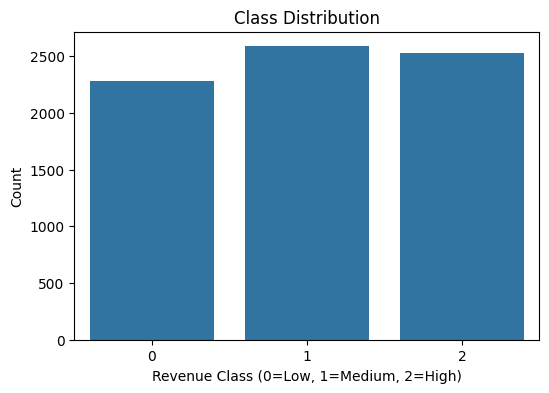

In [ ]:
# Convert revenue into classes
def revenue_to_class(revenue):
    if revenue < 9000000:
        return 0  # Low
    elif revenue < 50000000:
        return 1  # Medium
    else:
        return 2  # High


# Apply transformation
y = y_raw.apply(revenue_to_class)

# Display distribution
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Class Distribution")
plt.xlabel("Revenue Class (0=Low, 1=Medium, 2=High)")
plt.ylabel("Count")
plt.show()

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train-Test Split: 80%-20%")


Train-Test Split: 80%-20%


In [ ]:
X_train

,budget,popularity,runtime,release_year,release_month,release_day,profit,profit_margin,original_language_encoded,genre_Action,...,country_Taiwan,country_Thailand,country_Tunisia,country_Turkey,country_Ukraine,country_United Arab Emirates,country_United Kingdom,country_United States of America,country_Uruguay,country_Venezuela
1109,14500000,5.892859,82.0,2003.0,1.0,29.0,5.099721e+07,3.517049,14,1,...,0,0,0,0,0,0,0,0,0,0
6779,31192,1.585713,89.0,2009.0,9.0,1.0,8.542432e+06,6.643274,10,1,...,0,0,0,0,0,0,1,0,0,0
7259,70000000,20.303632,116.0,2016.0,12.0,21.0,1.197271e+08,2.441481,10,0,...,0,0,0,0,0,0,0,1,0,0
7039,9000000,7.550133,96.0,1976.0,12.0,20.0,2.897709e+07,3.219676,10,1,...,0,0,0,0,0,0,0,1,0,0
1964,3000000,1.036233,154.0,2010.0,2.0,26.0,9.000000e+06,3.000000,36,0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5191,0,0.453698,98.0,1989.0,8.0,16.0,4.009570e+06,0.000000,10,0,...,0,0,0,0,0,0,0,1,0,0
5226,20000000,8.772263,95.0,2012.0,4.0,12.0,1.220403e+07,0.610201,10,1,...,0,0,0,0,0,0,0,0,0,0
5390,70000000,15.099110,106.0,2009.0,6.0,11.0,1.197271e+08,2.080599,10,0,...,0,0,0,0,0,0,0,1,0,0
860,30000000,7.645827,113.0,2002.0,12.0,30.0,3.013805e+06,0.100460,10,0,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
X_test

,budget,popularity,runtime,release_year,release_month,release_day,profit,profit_margin,original_language_encoded,genre_Action,...,country_Taiwan,country_Thailand,country_Tunisia,country_Turkey,country_Ukraine,country_United Arab Emirates,country_United Kingdom,country_United States of America,country_Uruguay,country_Venezuela
2473,0,5.877599,98.0,1996.0,5.0,2.0,2.813194e+06,0.000000,10,1,...,0,0,0,0,0,0,0,1,0,0
6730,8000000,6.040486,98.0,1985.0,5.0,31.0,5.161289e+07,6.451611,10,0,...,0,0,0,0,0,0,0,1,0,0
2847,15000000,10.893332,154.0,2036.0,12.0,10.0,9.026444e+07,6.017629,10,0,...,0,0,0,0,0,0,1,0,0,0
169,0,3.676921,88.0,1995.0,4.0,12.0,2.596541e+06,0.000000,10,0,...,0,0,0,0,0,0,0,1,0,0
2036,35000000,10.989442,138.0,1997.0,9.0,19.0,6.871828e+07,1.963379,10,0,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,2200000,6.632663,118.0,2036.0,12.0,29.0,1.051794e+06,0.478088,10,0,...,0,0,0,0,0,0,1,1,0,0
2484,63000000,13.332102,128.0,2006.0,8.0,9.0,1.197271e+08,3.639474,10,0,...,0,0,0,0,0,0,0,1,0,0
6305,25000000,5.955203,99.0,2013.0,12.0,5.0,4.339019e+07,1.735608,10,0,...,0,0,0,0,0,0,1,0,0,0
110,950000,0.820911,76.0,2036.0,8.0,8.0,5.500000e+05,0.578947,10,0,...,0,0,0,0,0,0,0,1,0,0


In [ ]:
y_train.head()

,revenue
1109,2
6779,0
7259,2
7039,1
1964,1


In [ ]:

# Standardize features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train))
X_test_scaled = pd.DataFrame(scaler.transform(X_test))


In [ ]:
X_train_scaled.head()


,0,1,2,3,4,5,6,7,8,9,...,181,182,183,184,185,186,187,188,189,190
0,-0.165117,-0.378890,-1.369159,-0.048960,-1.723099,1.592583,0.503192,0.826273,0.461276,1.815112,...,-0.036792,-0.045076,-0.022521,-0.043153,-0.031857,-0.04692,-0.373058,-1.774024,-0.013,0.0
1,-0.794243,-1.224514,-0.989342,0.157044,0.648228,-1.654146,-0.549112,2.213774,-0.277565,1.815112,...,-0.036792,-0.045076,-0.022521,-0.043153,-0.031857,-0.04692,2.680548,-1.774024,-0.013,0.0
2,2.248110,2.450383,0.475665,0.397381,1.537476,0.664946,2.206764,0.348908,-0.277565,-0.550930,...,-0.036792,-0.045076,-0.022521,-0.043153,-0.031857,-0.04692,-0.373058,0.563690,-0.013,0.0
3,-0.404266,-0.053517,-0.609526,-0.975976,1.537476,0.548992,-0.042609,0.694291,-0.277565,1.815112,...,-0.036792,-0.045076,-0.022521,-0.043153,-0.031857,-0.04692,-0.373058,0.563690,-0.013,0.0
4,-0.665155,-1.332394,2.537526,0.191378,-1.426683,1.244720,-0.537771,0.596793,4.524902,-0.550930,...,-0.036792,-0.045076,-0.022521,-0.043153,-0.031857,-0.04692,2.680548,-1.774024,-0.013,0.0


In [ ]:
X_test_scaled.head()

,0,1,2,3,4,5,6,7,8,9,...,181,182,183,184,185,186,187,188,189,190
0,-0.795600,-0.381886,-0.501007,-0.289297,-0.537435,-1.538192,-0.691120,-0.734686,-0.277565,1.815112,...,-0.036792,-0.045076,-0.022521,-0.043153,-0.031857,-0.04692,-0.373058,0.563690,-0.013,0.0
1,-0.447747,-0.349907,-0.501007,-0.666970,-0.537435,1.824493,0.518453,2.128709,-0.277565,-0.550930,...,-0.036792,-0.045076,-0.022521,-0.043153,-0.031857,-0.04692,-0.373058,0.563690,-0.013,0.0
2,-0.143376,0.602855,2.537526,1.084060,1.537476,-0.610555,1.476488,1.936096,-0.277565,-0.550930,...,-0.036792,-0.045076,-0.022521,-0.043153,-0.031857,-0.04692,2.680548,-1.774024,-0.013,0.0
3,-0.795600,-0.813946,-1.043602,-0.323631,-0.833851,-0.378645,-0.696490,-0.734686,-0.277565,-0.550930,...,-0.036792,-0.045076,-0.022521,-0.043153,-0.031857,-0.04692,-0.373058,0.563690,-0.013,0.0
4,0.726255,0.621724,1.669374,-0.254963,0.648228,0.433037,0.942435,0.136713,-0.277565,-0.550930,...,-0.036792,-0.045076,-0.022521,-0.043153,-0.031857,-0.04692,-0.373058,0.563690,-0.013,0.0



Training SVM with kernel=linear, C=0.1
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.95       442
           1       0.96      0.93      0.94       534
           2       0.99      0.98      0.99       504

    accuracy                           0.96      1480
   macro avg       0.96      0.96      0.96      1480
weighted avg       0.96      0.96      0.96      1480

Accuracy: 0.9588


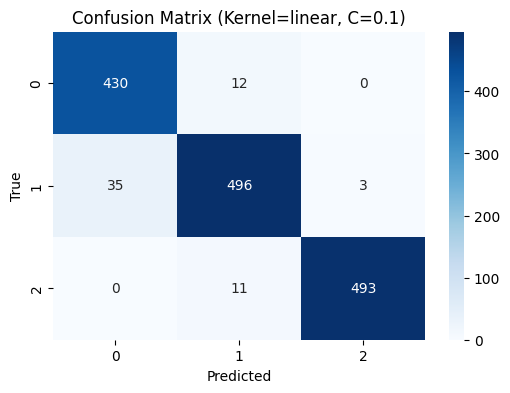


Training SVM with kernel=linear, C=1
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.97      0.97       442
           1       0.96      0.98      0.97       534
           2       0.99      0.99      0.99       504

    accuracy                           0.98      1480
   macro avg       0.98      0.98      0.98      1480
weighted avg       0.98      0.98      0.98      1480

Accuracy: 0.9777


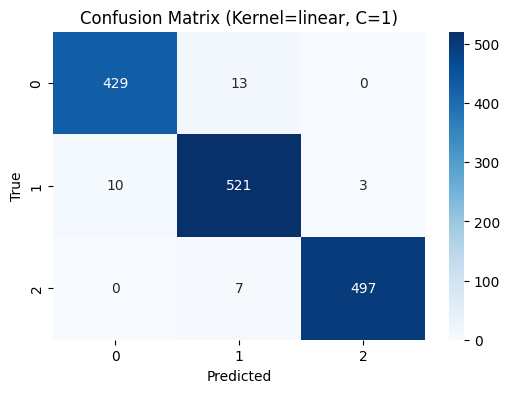


Training SVM with kernel=linear, C=3
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       442
           1       0.97      0.98      0.97       534
           2       1.00      0.98      0.99       504

    accuracy                           0.98      1480
   macro avg       0.98      0.98      0.98      1480
weighted avg       0.98      0.98      0.98      1480

Accuracy: 0.9804


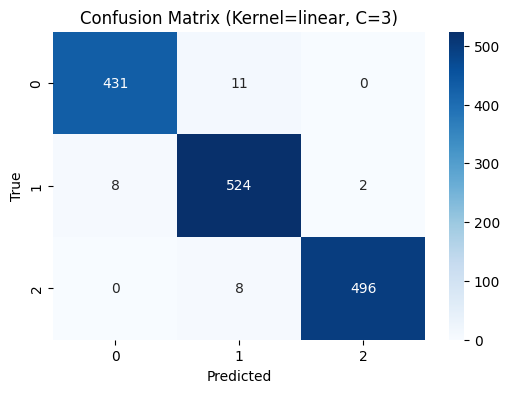


Training SVM with kernel=rbf, C=0.1
Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.69      0.68       442
           1       0.65      0.78      0.71       534
           2       0.99      0.74      0.85       504

    accuracy                           0.74      1480
   macro avg       0.77      0.74      0.74      1480
weighted avg       0.77      0.74      0.75      1480

Accuracy: 0.7405


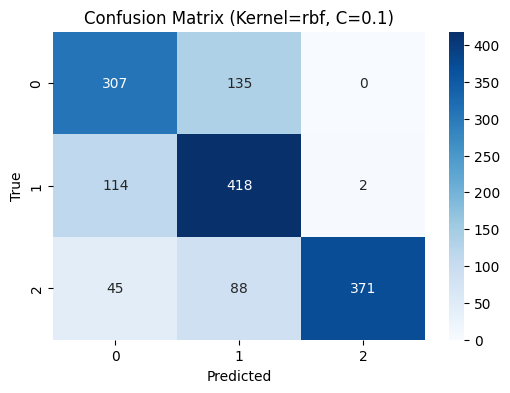


Training SVM with kernel=rbf, C=1
Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.83      0.80       442
           1       0.80      0.82      0.81       534
           2       0.99      0.92      0.95       504

    accuracy                           0.86      1480
   macro avg       0.86      0.85      0.86      1480
weighted avg       0.86      0.86      0.86      1480

Accuracy: 0.8554


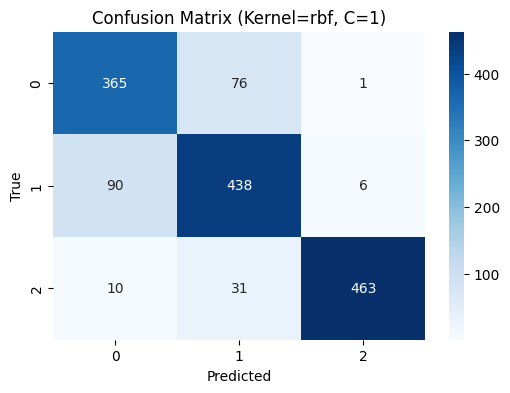


Training SVM with kernel=rbf, C=3
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86       442
           1       0.86      0.86      0.86       534
           2       0.98      0.93      0.96       504

    accuracy                           0.89      1480
   macro avg       0.89      0.89      0.89      1480
weighted avg       0.89      0.89      0.89      1480

Accuracy: 0.8912


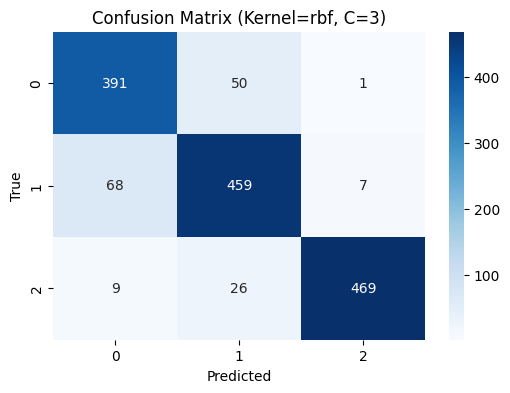


Training SVM with kernel=poly, C=0.1
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.08      0.15       442
           1       0.42      0.93      0.57       534
           2       0.81      0.38      0.52       504

    accuracy                           0.49      1480
   macro avg       0.63      0.46      0.41      1480
weighted avg       0.63      0.49      0.43      1480

Accuracy: 0.4885


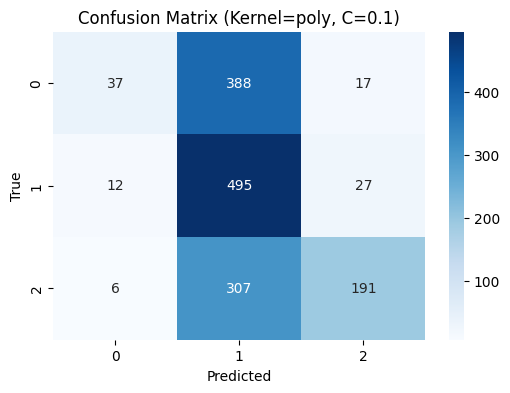


Training SVM with kernel=poly, C=1
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.20      0.31       442
           1       0.43      0.92      0.58       534
           2       0.94      0.37      0.53       504

    accuracy                           0.52      1480
   macro avg       0.68      0.50      0.47      1480
weighted avg       0.68      0.52      0.48      1480

Accuracy: 0.5176


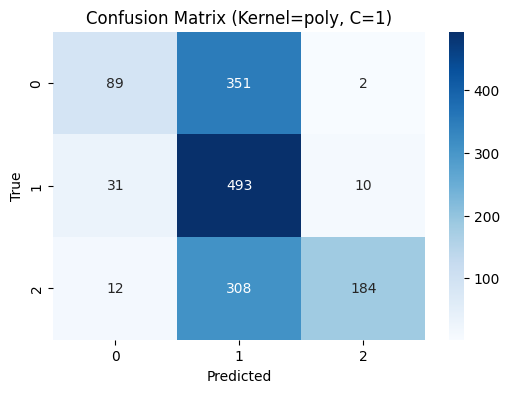


Training SVM with kernel=poly, C=3
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.27      0.39       442
           1       0.44      0.90      0.59       534
           2       0.95      0.43      0.59       504

    accuracy                           0.55      1480
   macro avg       0.69      0.53      0.52      1480
weighted avg       0.69      0.55      0.53      1480

Accuracy: 0.5500


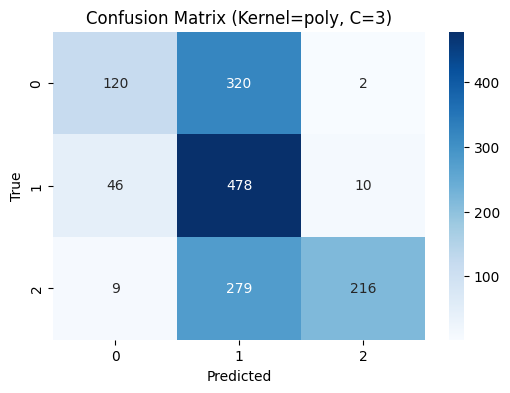

In [ ]:
# Kernels and C values
kernels = ['linear', 'rbf', 'poly']
c_values = [0.1, 1, 3]

results = {}

# Loop over kernels and C values
for kernel in kernels:
    results[kernel] = {}
    for c in c_values:
        print(f"\nTraining SVM with kernel={kernel}, C={c}")
        model = SVC(kernel=kernel, C=c, random_state=42)
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

        cm = confusion_matrix(y_test, y_pred)
        cr = classification_report(y_test, y_pred)
        acc = accuracy_score(y_test, y_pred)

        # print("Confusion Matrix:\n", cm)
        print("Classification Report:\n", cr)
        print(f"Accuracy: {acc:.4f}")

        results[kernel][c] = {'model': model, 'confusion_matrix': cm, 'classification_report': cr, 'accuracy': acc}
         # Plot confusion matrix
        plt.figure(figsize=(6,4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix (Kernel={kernel}, C={c})')
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.show()


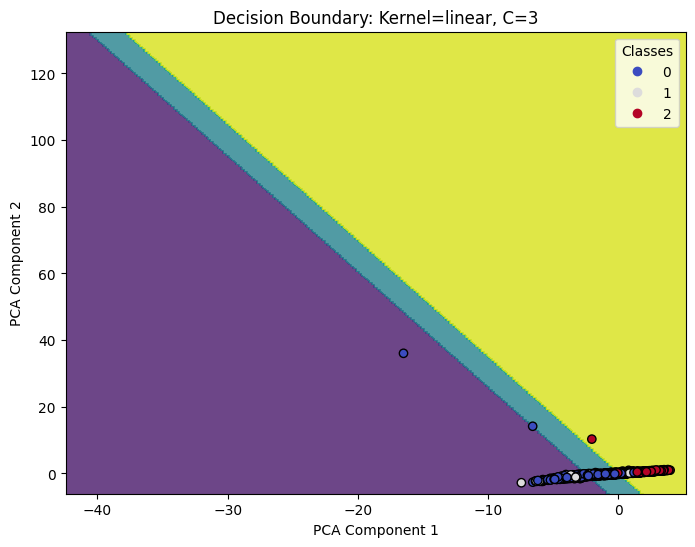

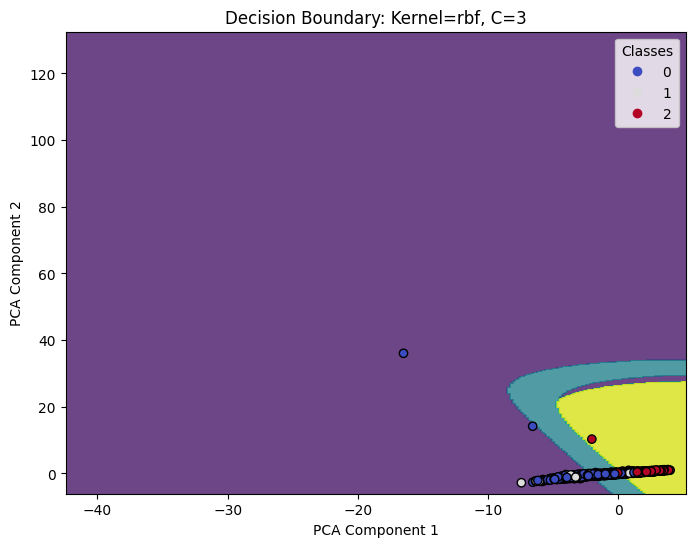

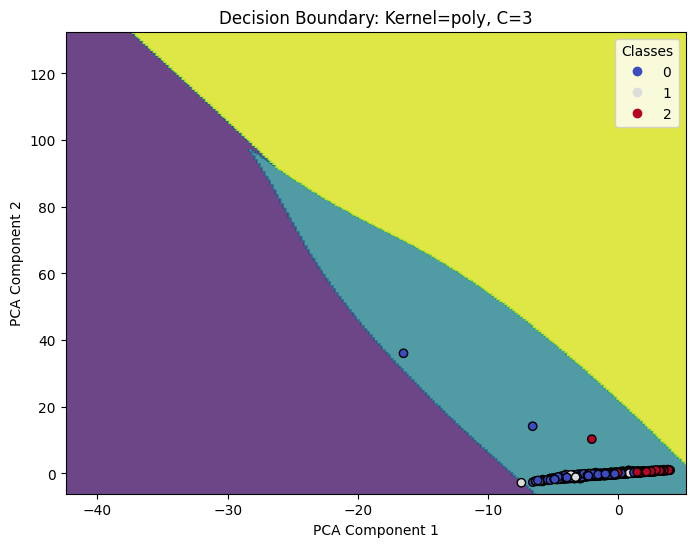



Summary of SVM Results:

Kernel: linear
C=0.1: Accuracy=0.9588
C=1: Accuracy=0.9777
C=3: Accuracy=0.9804

Kernel: rbf
C=0.1: Accuracy=0.7405
C=1: Accuracy=0.8554
C=3: Accuracy=0.8912

Kernel: poly
C=0.1: Accuracy=0.4885
C=1: Accuracy=0.5176
C=3: Accuracy=0.5500


In [ ]:
# Visualizations: Decision Boundaries using PCA (2 components)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

for kernel in kernels:
    best_c = max(results[kernel], key=lambda x: results[kernel][x]['accuracy'])
    best_model = results[kernel][3]['model']

    plt.figure(figsize=(8,6))
    plt.title(f"Decision Boundary: Kernel={kernel}, C={best_c}")

    # Mesh for plotting (fixed step size)
    x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
    y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.2), np.arange(y_min, y_max, 0.2))  # Step size = 0.2

    Z = best_model.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()]))
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.8)
    scatter = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, edgecolors='k', marker='o', cmap=plt.cm.coolwarm)
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.legend(*scatter.legend_elements(), title="Classes")
    plt.show()


    # # Create mesh to plot boundary
    # x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
    # y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
    # xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.2), np.arange(y_min, y_max, 0.2))

    # Z = best_model.predict(pca.inverse_transform(np.c_[xx.ravel(), yy.ravel()]))
    # Z = Z.reshape(xx.shape)

    # plt.contourf(xx, yy, Z, alpha=0.8)
    # scatter = plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, edgecolors='k', marker='o', cmap=plt.cm.coolwarm)
    # plt.xlabel('PCA Component 1')
    # plt.ylabel('PCA Component 2')
    # plt.legend(*scatter.legend_elements(), title="Classes")
    # plt.show()

# Summary of Results
print("\n\nSummary of SVM Results:")
for kernel in kernels:
    print(f"\nKernel: {kernel}")
    for c in c_values:
        acc = results[kernel][c]['accuracy']
        print(f"C={c}: Accuracy={acc:.4f}")

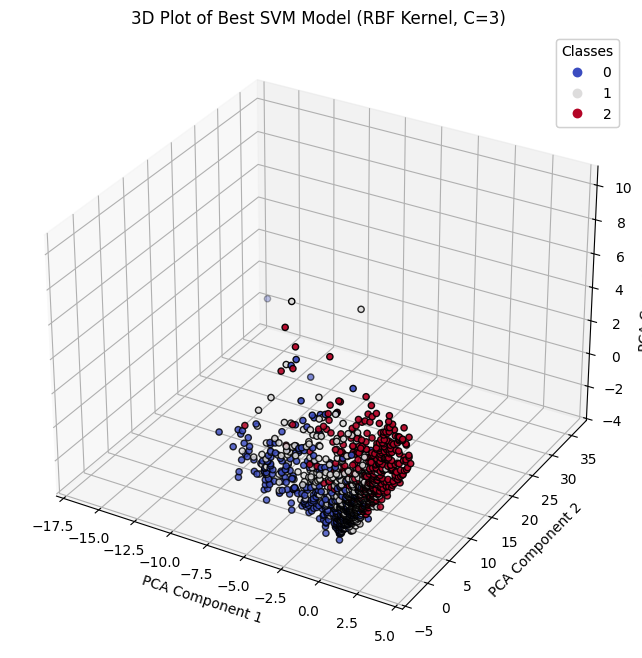

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# 1. Do PCA with 3 components
pca_3d = PCA(n_components=3)
X_train_pca3 = pca_3d.fit_transform(X_train_scaled)
X_test_pca3 = pca_3d.transform(X_test_scaled)

# 2. Get best model (RBF, )
best_model = results['rbf'][3]['model']

# 3. Predict
y_pred_best = best_model.predict(X_test_scaled)

# 4. Plot 3D Scatter
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_test_pca3[:, 0], X_test_pca3[:, 1], X_test_pca3[:, 2],
                     c=y_pred_best, cmap=plt.cm.coolwarm, edgecolor='k')

ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.set_title('3D Plot of Best SVM Model (RBF Kernel, C=3)')
legend = ax.legend(*scatter.legend_elements(), title="Classes", loc='best')
ax.add_artist(legend)
plt.show()


# Ensemble Method Algorithms

In [ ]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# XGBoost
xgb_model = XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

# AdaBoost
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_model.fit(X_train, y_train)
ada_pred = ada_model.predict(X_test)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [03:16:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Model: Random Forest
Accuracy: 0.9588

Classification Report:
              precision    recall  f1-score   support

         Low       0.96      0.96      0.96       442
      Medium       0.93      0.96      0.94       534
        High       0.99      0.96      0.97       504

    accuracy                           0.96      1480
   macro avg       0.96      0.96      0.96      1480
weighted avg       0.96      0.96      0.96      1480



<Figure size 1800x1200 with 0 Axes>

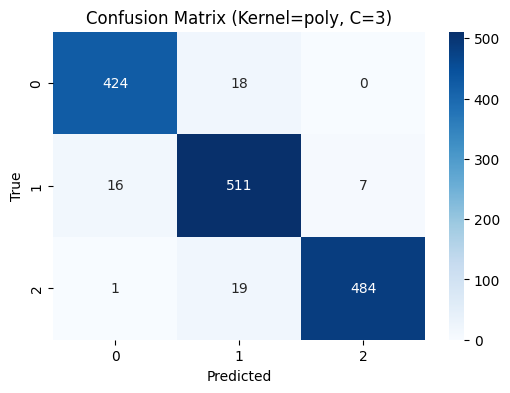

Model: XGBoost
Accuracy: 0.9912

Classification Report:
              precision    recall  f1-score   support

         Low       0.99      0.99      0.99       442
      Medium       0.99      0.99      0.99       534
        High       1.00      1.00      1.00       504

    accuracy                           0.99      1480
   macro avg       0.99      0.99      0.99      1480
weighted avg       0.99      0.99      0.99      1480



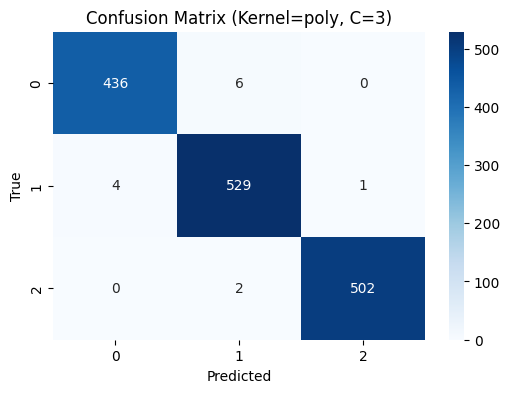

Model: AdaBoost
Accuracy: 0.9372

Classification Report:
              precision    recall  f1-score   support

         Low       0.97      0.90      0.93       442
      Medium       0.86      0.98      0.92       534
        High       1.00      0.93      0.96       504

    accuracy                           0.94      1480
   macro avg       0.95      0.93      0.94      1480
weighted avg       0.94      0.94      0.94      1480



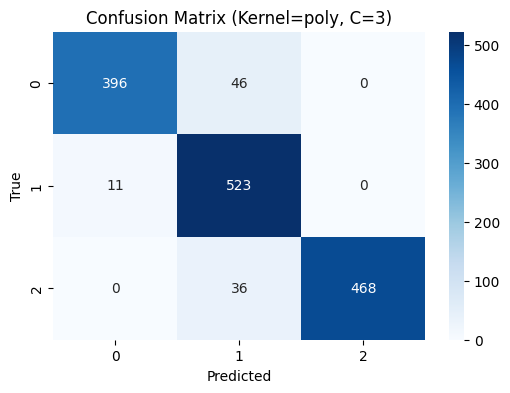

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Assume these models were already trained
models = {
    "Random Forest": (rf_model, rf_pred),
    "XGBoost": (xgb_model, xgb_pred),
    "AdaBoost": (ada_model, ada_pred)
}

# Set figure size for confusion matrices
plt.figure(figsize=(18, 12))

# Loop through models
for idx, (name, (model, y_pred)) in enumerate(models.items()):
    # 1. Accuracy
    acc = accuracy_score(y_test, y_pred)
    print(f"===============================")
    print(f"Model: {name}")
    print(f"Accuracy: {acc:.4f}")

    # 2. Classification report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=["Low", "Medium", "High"]))
    # 3. Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # plt.subplot(2, 2, idx + 1)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix (Kernel={kernel}, C={c})')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()


